## Bike Rental Demand Prediction

### Libraries

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### EDA

In [81]:
df = pd.read_csv("Dataset.csv")
# Display all columns
pd.set_option('display.max_columns', None)
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2011,springer,2011,1,0,No,6,No work,Clear,0.24,0.2879,0.81,0,3,13,16
1,2,01-01-2011,springer,2011,1,1,No,6,No work,Clear,0.22,0.2727,0.8,0,8,32,40
2,3,01-01-2011,springer,2011,1,2,No,6,No work,Clear,0.22,0.2727,?,0,5,27,32
3,4,01-01-2011,springer,2011,1,3,No,6,No work,Clear,0.24,0.2879,0.75,0,3,10,13
4,5,01-01-2011,springer,2011,1,4,No,6,No work,Clear,0.24,0.2879,0.75,0,0,1,1


In [82]:
df.info()
#Its considering "?" as a data entry, so we need to replace it with NaN

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   instant     17379 non-null  int64
 1   dteday      17379 non-null  str  
 2   season      17379 non-null  str  
 3   yr          17379 non-null  str  
 4   mnth        17379 non-null  str  
 5   hr          17379 non-null  int64
 6   holiday     17379 non-null  str  
 7   weekday     17379 non-null  int64
 8   workingday  17379 non-null  str  
 9   weathersit  17379 non-null  str  
 10  temp        17379 non-null  str  
 11  atemp       17379 non-null  str  
 12  hum         17379 non-null  str  
 13  windspeed   17379 non-null  str  
 14  casual      17379 non-null  str  
 15  registered  17379 non-null  str  
 16  cnt         17379 non-null  int64
dtypes: int64(4), str(13)
memory usage: 3.3 MB


In [83]:
df.replace("?",np.nan,inplace=True)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2011,springer,2011,1,0,No,6,No work,Clear,0.24,0.2879,0.81,0,3,13,16
1,2,01-01-2011,springer,2011,1,1,No,6,No work,Clear,0.22,0.2727,0.8,0,8,32,40
2,3,01-01-2011,springer,2011,1,2,No,6,No work,Clear,0.22,0.2727,NaN,0,5,27,32
3,4,01-01-2011,springer,2011,1,3,No,6,No work,Clear,0.24,0.2879,0.75,0,3,10,13
4,5,01-01-2011,springer,2011,1,4,No,6,No work,Clear,0.24,0.2879,0.75,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,31-12-2012,springer,2012,12,19,No,1,Working Day,Mist,0.26,0.2576,0.6,0.1642,11,108,119
17375,17376,31-12-2012,springer,2012,12,20,No,1,Working Day,Mist,0.26,0.2576,0.6,0.1642,8,81,89
17376,17377,31-12-2012,springer,2012,12,21,No,1,Working Day,Clear,NaN,0.2576,0.6,0.1642,7,83,90
17377,17378,31-12-2012,springer,2012,12,22,No,1,Working Day,Clear,0.26,0.2727,0.56,0.1343,13,48,61


In [84]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   instant     17379 non-null  int64
 1   dteday      17379 non-null  str  
 2   season      17373 non-null  str  
 3   yr          17378 non-null  str  
 4   mnth        17378 non-null  str  
 5   hr          17379 non-null  int64
 6   holiday     17378 non-null  str  
 7   weekday     17379 non-null  int64
 8   workingday  17374 non-null  str  
 9   weathersit  17375 non-null  str  
 10  temp        17368 non-null  str  
 11  atemp       17373 non-null  str  
 12  hum         17373 non-null  str  
 13  windspeed   17374 non-null  str  
 14  casual      17378 non-null  str  
 15  registered  17378 non-null  str  
 16  cnt         17379 non-null  int64
dtypes: int64(4), str(13)
memory usage: 3.3 MB


In [85]:
df.dtypes

instant       int64
dteday          str
season          str
yr              str
mnth            str
hr            int64
holiday         str
weekday       int64
workingday      str
weathersit      str
temp            str
atemp           str
hum             str
windspeed       str
casual          str
registered      str
cnt           int64
dtype: object

In [86]:
df['dteday'] = pd.to_datetime(df['dteday'],dayfirst=True)

In [87]:
numeric_cols = ['temp','atemp','hum','windspeed','cnt','mnth','yr']
categorical_cols = ['season','holiday','workingday','weathersit']

In [88]:
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric) 

In [89]:
df.dtypes

instant                int64
dteday        datetime64[us]
season                   str
yr                   float64
mnth                 float64
hr                     int64
holiday                  str
weekday                int64
workingday               str
weathersit               str
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
casual                   str
registered               str
cnt                    int64
dtype: object

In [90]:
df.isnull().sum()

instant        0
dteday         0
season         6
yr             1
mnth           1
hr             0
holiday        1
weekday        0
workingday     5
weathersit     4
temp          11
atemp          6
hum            6
windspeed      5
casual         1
registered     1
cnt            0
dtype: int64

In [91]:
df.duplicated().sum()

np.int64(0)

In [92]:
#Filling missing values in categorical columns with mode
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [93]:
#Filling missing values in numerical columns with mean
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

Dropping rows with missing values in 'casual' and 'registered' since these are count variables and only one row is affected.

In [94]:
df = df.dropna(subset=['casual','registered']).reset_index(drop=True) #resets index

In [95]:
df['casual'] = df['casual'].astype(int)
df['registered'] = df['registered'].astype(int)

In [96]:
df['yr'] = df['yr'].astype(int)
df['mnth'] = df['mnth'].astype(int)

In [97]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [98]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17378 entries, 0 to 17377
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17378 non-null  int64         
 1   dteday      17378 non-null  datetime64[us]
 2   season      17378 non-null  str           
 3   yr          17378 non-null  int64         
 4   mnth        17378 non-null  int64         
 5   hr          17378 non-null  int64         
 6   holiday     17378 non-null  str           
 7   weekday     17378 non-null  int64         
 8   workingday  17378 non-null  str           
 9   weathersit  17378 non-null  str           
 10  temp        17378 non-null  float64       
 11  atemp       17378 non-null  float64       
 12  hum         17378 non-null  float64       
 13  windspeed   17378 non-null  float64       
 14  casual      17378 non-null  int64         
 15  registered  17378 non-null  int64         
 16  cnt         17378 non-null  int64

### Visualizations

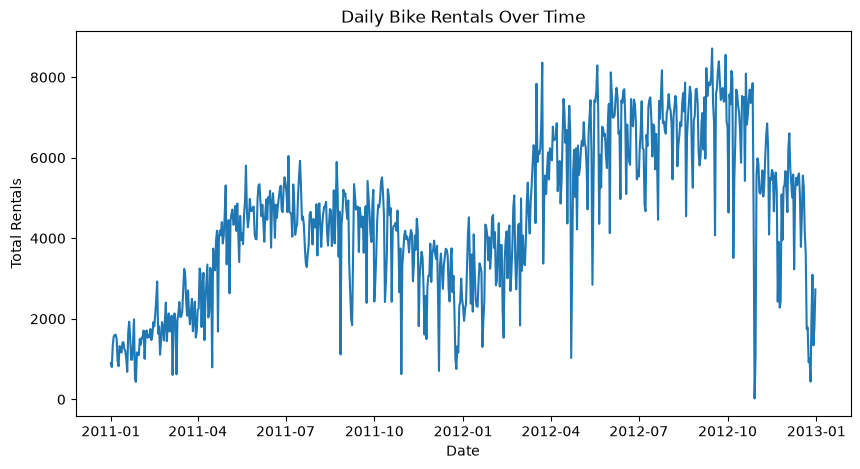

In [99]:
#Daily Rentals Over Time
daily_df = df.groupby('dteday')['cnt'].sum()
plt.figure(figsize=(10,5))
plt.plot(daily_df)
plt.title("Daily Bike Rentals Over Time")
plt.xlabel("Date")
plt.ylabel("Total Rentals")
plt.show()

* Rentals increase from 2011 to 2012 showing overall growth
* Higher rentals in mid-year and lower at start/end indicate seasonality
* Noticeable daily fluctuations suggest external factors like weather
* Few sharp drops may indicate anomalies or special conditions

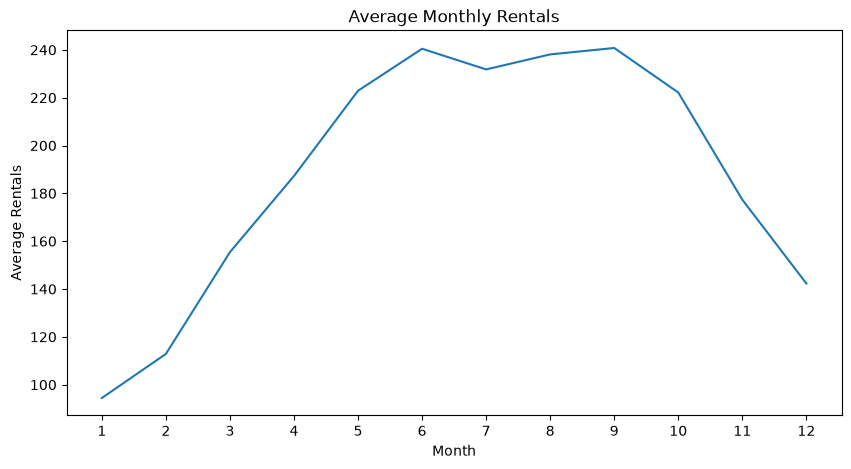

In [100]:
#Monthly Rentals Over Time
monthly_df = df.groupby('mnth')['cnt'].mean()
plt.figure(figsize=(10,5))
plt.plot(monthly_df)
plt.title("Average Monthly Rentals")
plt.xlabel("Month")
plt.ylabel("Average Rentals")
plt.xticks(ticks=range(1,13))
plt.show()

* Rentals increase steadily from january to june
* Peak rentals occur around june to september
* Slight dip in july but overall high demand continues
* Rentals decline after october towards december
* Lowest rentals are at the beginning and end of the year

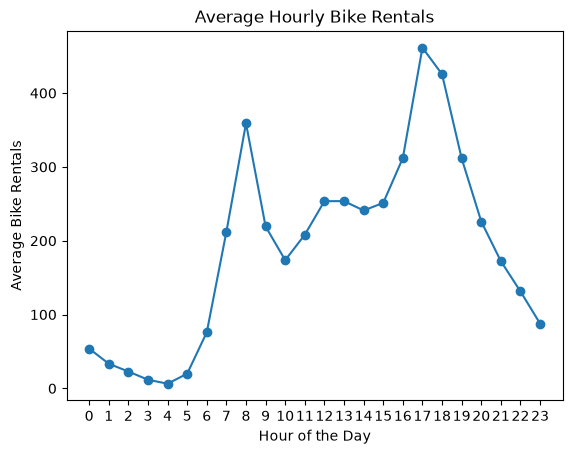

In [101]:
#Hourly Rentals Over Time
df.groupby('hr')['cnt'].mean().plot(marker='o')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Bike Rentals')
plt.title('Average Hourly Bike Rentals')
plt.xticks(range(0, 24))
plt.show()

* Rentals are lowest during early morning hours (midnight to 5 am)
* Sharp increase starts from morning, peaking around 8 am
* Slight dip during late morning and midday
* Highest peak occurs in the evening around 5–6 pm
* Rentals decline steadily after evening towards night
* Pattern matches office commute hours (morning + evening peaks)



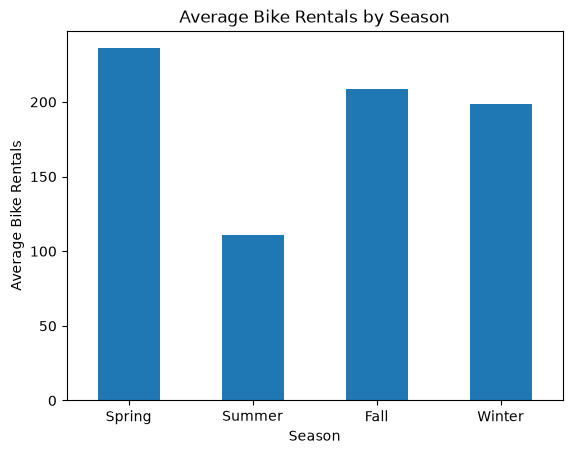

In [102]:
#Seasonal Rentals
df.groupby('season')['cnt'].mean().plot(kind='bar')
plt.xlabel('Season')
plt.ylabel('Average Bike Rentals')
plt.title('Average Bike Rentals by Season')
#Adding season labels
plt.xticks(ticks=[0,1,2,3], labels=['Spring','Summer','Fall','Winter'], rotation=0)
plt.show()

* Highest rentals occur in spring
* Fall and winter also show relatively high rentals
* Summer has the lowest rentals
* Moderate weather seasons have higher demand compared to extreme conditions


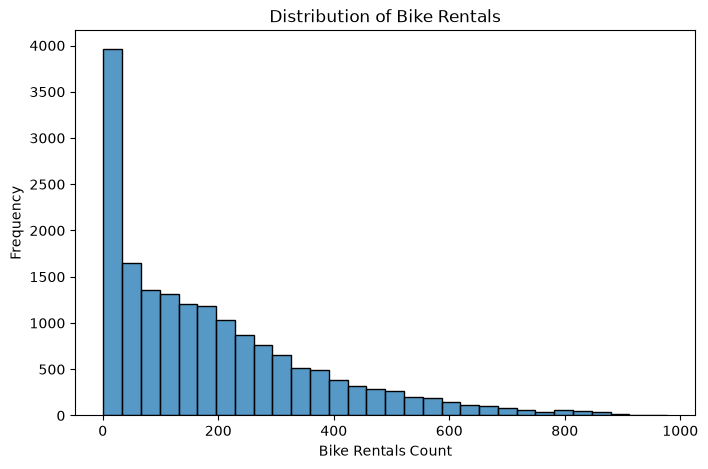

In [103]:
# Distribution of Bike Rentals
plt.figure(figsize=(8,5))
sns.histplot(df['cnt'], bins=30)
plt.title("Distribution of Bike Rentals")
plt.xlabel("Bike Rentals Count")
plt.ylabel("Frequency")
plt.show()

* Most rentals are concentrated at lower values
* Frequency decreases as rental count increases
* Very high rental counts are rare
* Distribution is right-skewed
* Presence of some extreme high-value observations


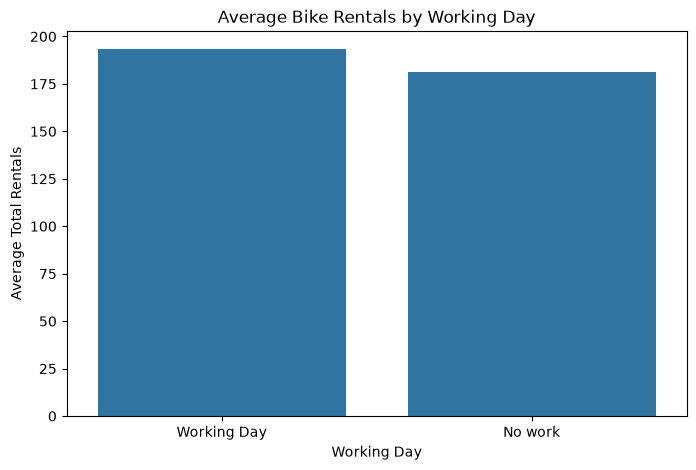

In [104]:
#Average Bike Rentals by Working Day
workingday_rentals = df.groupby('workingday')['cnt'].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=workingday_rentals.index,y=workingday_rentals.values)
plt.title('Average Bike Rentals by Working Day')
plt.xlabel('Working Day')
plt.ylabel('Average Total Rentals')
plt.show()

* Bike rentals are higher on working days, with an average of around 193 rentals.
* On non-working days, the average is slightly lower, at around 181 rentals.
* This shows that people tend to rent bikes more on working days than on days when there is no work.

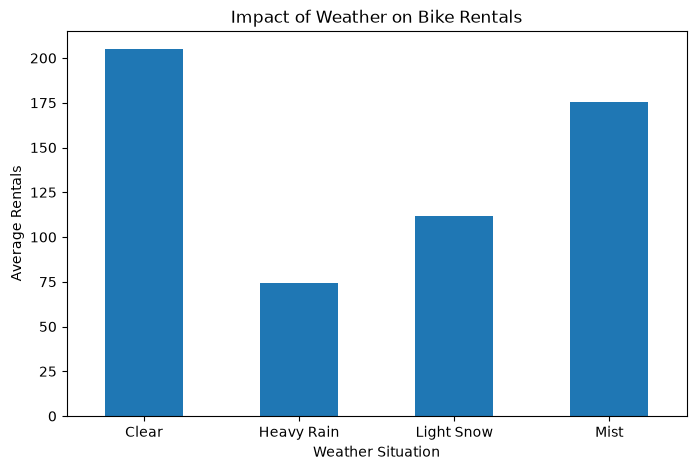

In [105]:
# Impact of Weather on Bike Rentals
plt.figure(figsize=(8,5))
df.groupby('weathersit')['cnt'].mean().plot(kind='bar')
plt.title("Impact of Weather on Bike Rentals")
plt.xlabel("Weather Situation")
plt.ylabel("Average Rentals")
plt.xticks(rotation=0)
plt.show()

* Highest rentals occur during clear weather
* Rentals decrease as weather conditions worsen
* Heavy rain has the lowest rentals
* Mist conditions still maintain relatively high rentals
* Light snow shows moderate rentals compared to rain


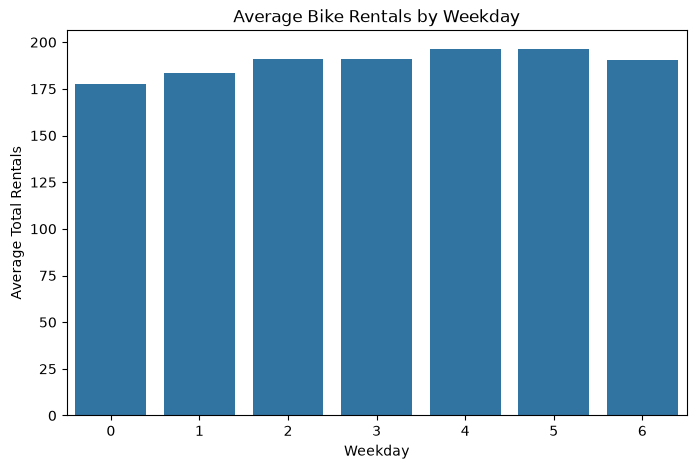

In [106]:
#Average Bike Rentals by Weekday
weekday_rentals = df.groupby('weekday')['cnt'].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=weekday_rentals.index,y=weekday_rentals.values)
plt.title('Average Bike Rentals by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Average Total Rentals')
plt.show()

* Bike rentals are lowest on weekday 0, with around 178 rentals.
* Rentals gradually increase during the week and reach the highest level on weekdays 4 and 5, at around 196 rentals.
* On weekday 6, rentals decrease slightly to around 190.

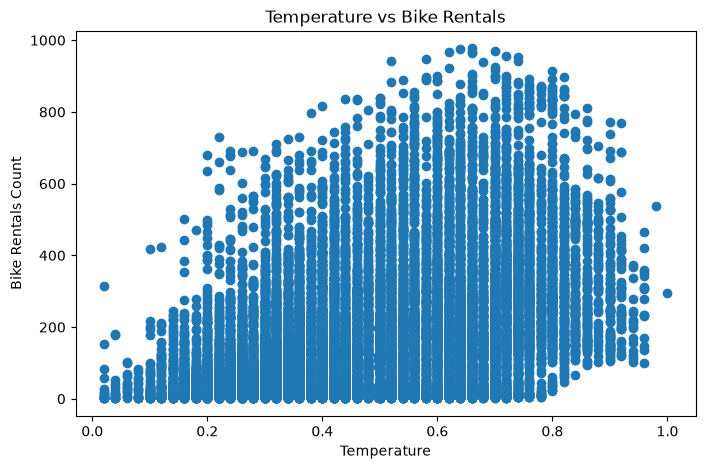

In [107]:
# Scatter Plot: Temperature vs Bike Rentals
plt.figure(figsize=(8,5))
plt.scatter(df['temp'], df['cnt'])
plt.title("Temperature vs Bike Rentals")
plt.xlabel("Temperature")
plt.ylabel("Bike Rentals Count")
plt.show()

* Rentals increase as temperature rises initially
* Highest rentals occur at moderate to warm temperatures
* Rentals decrease at very high temperatures
* Very low temperatures also have low rentals
* Relationship is non-linear with a peak in mid-range temperatures


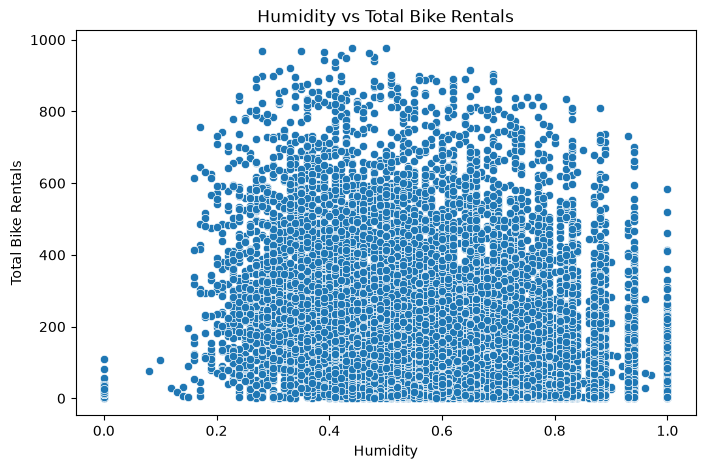

In [108]:
#Humidity vs Total Bike Rentals
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['hum'],y=df['cnt'])
plt.title('Humidity vs Total Bike Rentals')
plt.xlabel('Humidity')
plt.ylabel('Total Bike Rentals')
plt.show()

* The points are widely scattered, so there is no clear relationship between humidity and bike rentals.
* Most bike rentals occur when humidity is between around 0.3 and 0.8.
* Even at similar humidity levels, the number of rentals varies a lot.
* Overall, humidity does not seem to have a strong effect on total bike rentals.

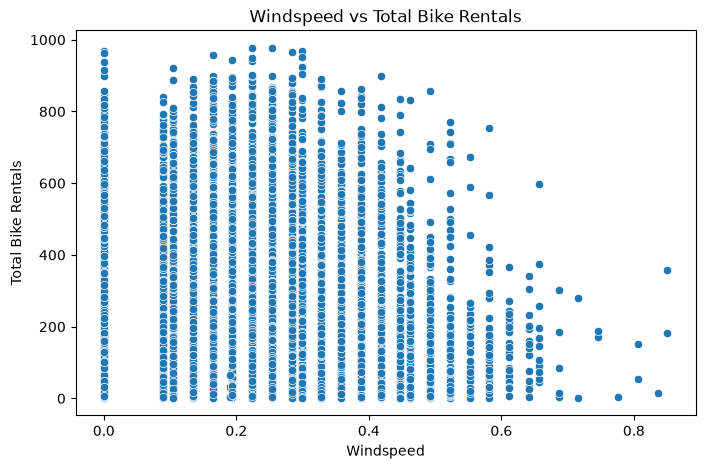

In [109]:
#Windspeed vs Total Bike Rentals
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['windspeed'],y=df['cnt'])
plt.title('Windspeed vs Total Bike Rentals')
plt.xlabel('Windspeed')
plt.ylabel('Total Bike Rentals')
plt.show()

* Bike rentals are generally higher when the windspeed is low.
* As windspeed increases, the number of bike rentals tends to decrease.
* At higher windspeeds, there are fewer rentals and the maximum rental count also becomes lower.
* Overall, there seems to be a negative relationship between windspeed and bike rentals.

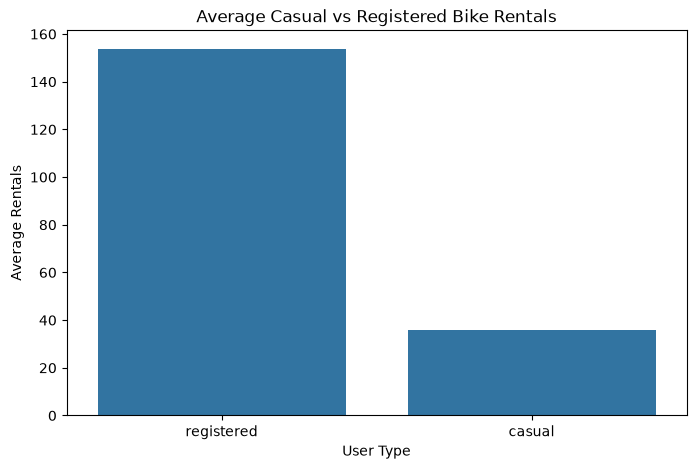

In [110]:
#Average Casual vs Registered Bike Rentals
user_types = df[['casual', 'registered']].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=user_types.index,y=user_types.values)
plt.title('Average Casual vs Registered Bike Rentals')
plt.xlabel('User Type')
plt.ylabel('Average Rentals')
plt.show()

* Registered users have a much higher average number of bike rentals, around 153.
* Casual users have a lower average, around 35 rentals.
* This shows that registered users use the bike rental service much more than casual users.

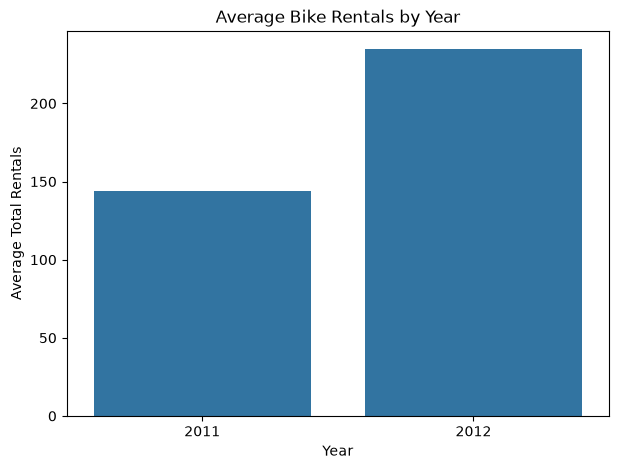

In [111]:
#Average Bike Rentals by Year
year_rentals = df.groupby('yr')['cnt'].mean()
plt.figure(figsize=(7, 5))
sns.barplot(x=year_rentals.index,y=year_rentals.values)
plt.title('Average Bike Rentals by Year')
plt.xlabel('Year')
plt.ylabel('Average Total Rentals')
plt.show()

* The average bike rentals increased from around 145 in 2011 to around 235 in 2012.
* There was a significant increase in bike rentals in 2012 compared to 2011.

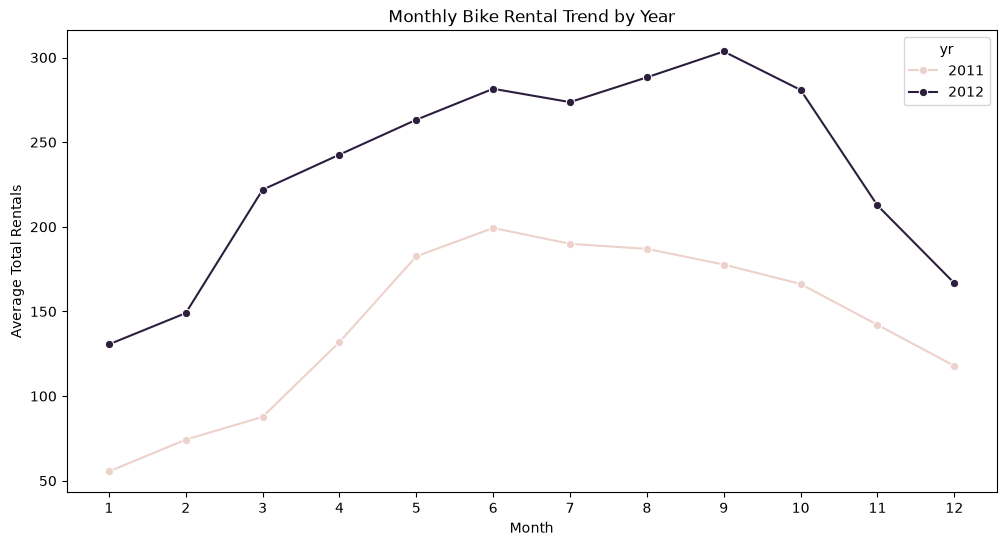

In [112]:
#Monthly Bike Rental Trend by Year
year_month_rentals = df.groupby(['yr', 'mnth'])['cnt'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=year_month_rentals,x='mnth',y='cnt',hue='yr',marker='o')
plt.title('Monthly Bike Rental Trend by Year')
plt.xlabel('Month')
plt.ylabel('Average Total Rentals')
plt.xticks(range(1, 13))
plt.show()

* Bike rentals were higher in 2012 than in 2011 for every month.
* In both years, rentals generally increase from the beginning of the year and reach higher levels around the middle of the year.
* In 2011, rentals are highest around June, while in 2012 they reach their highest point in September.
* After the peak, bike rentals gradually decrease toward the end of the year.

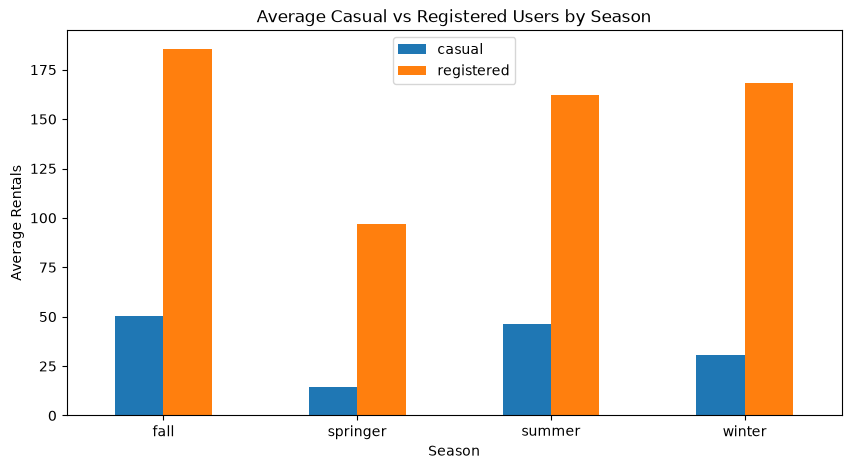

In [113]:
#Average Casual vs Registered Users by Season
season_users = df.groupby('season')[['casual', 'registered']].mean()
season_users.plot(kind='bar',figsize=(10, 5))
plt.title('Average Casual vs Registered Users by Season')
plt.xlabel('Season')
plt.ylabel('Average Rentals')
plt.xticks(rotation=0)
plt.show()

* Registered users have much higher rentals than casual users in every season.
* Fall has the highest average rentals for both casual and registered users.
* Spring has the lowest rentals for both user types.
* Summer and winter also have relatively high rentals, especially for registered users.
* Overall, registered users use the bike rental service much more than casual users in all seasons.

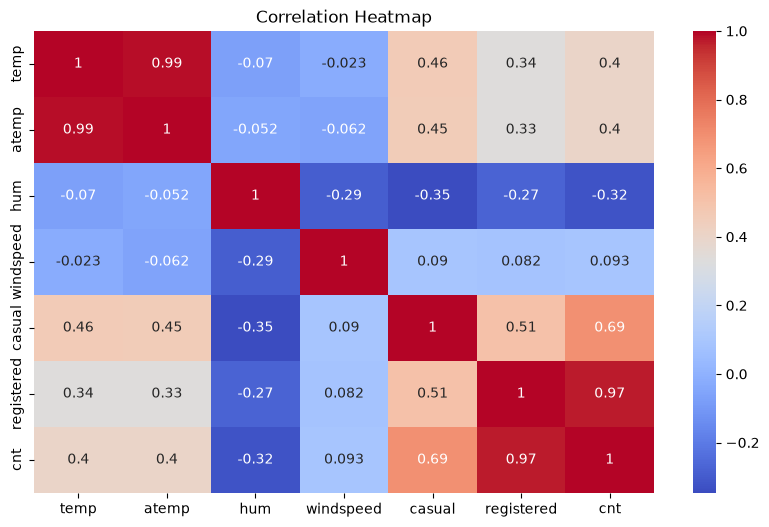

In [114]:
#Correlation Heatmap
corr_cols = ['temp','atemp','hum','windspeed','casual','registered','cnt']
plt.figure(figsize=(10,6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

- Temperature and atemp are almost perfectly correlated (0.99), indicating redundancy between features.
- Registered users have a very strong correlation (0.97) with total rentals, showing they dominate usage.
- Casual users also show a strong positive correlation (0.69) with total rentals.
- Humidity has a moderate negative correlation (-0.32), meaning higher humidity reduces rentals.
- Windspeed has very weak correlation (~0.09), indicating minimal impact on rentals.
- Temperature has a moderate positive impact (~0.40), suggesting better weather increases bike usage.
- High correlation between temp and atemp may cause multicollinearity and one can be removed during modeling.

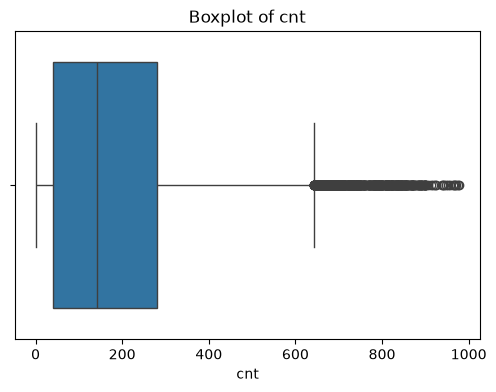

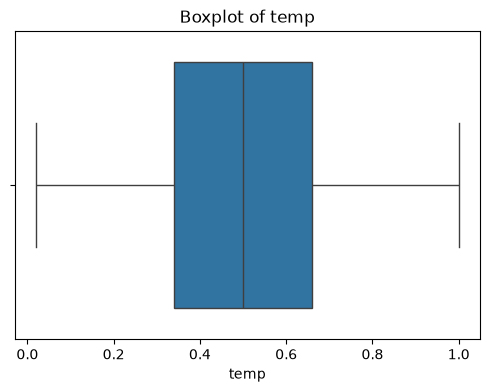

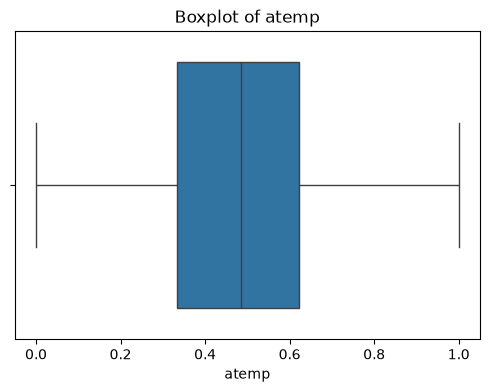

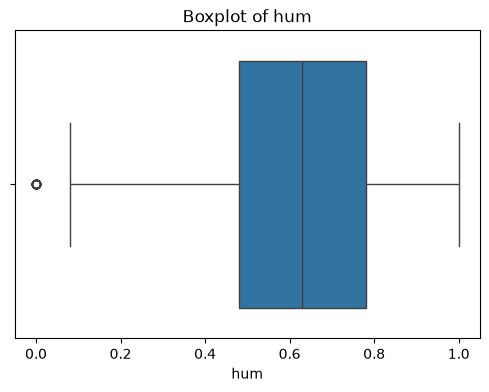

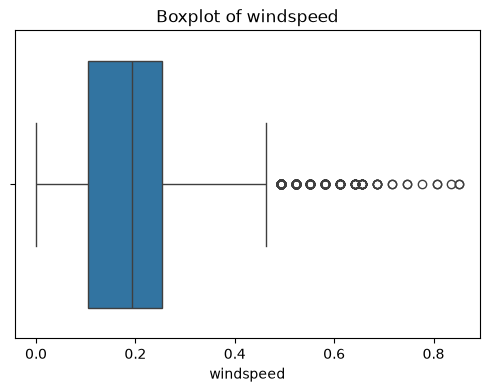

In [115]:
#Boxplots
num_cols = ['cnt','temp','atemp','hum','windspeed']
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

* There are many high values in cnt. These are not errors. They show times when a lot of people rented bikes (like busy hours or weekends).
* Most columns are normal. Only humidity and windspeed have some extreme values. 

### Outlier Removal

In [116]:
#Removing outliers using IQR method for 'hum' and 'windspeed' only.
df_clean = df.copy()
cols = ['hum','windspeed']
for col in cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1-1.5*IQR
    upper = Q3+1.5*IQR
    df_clean = df_clean[df_clean[col]>=lower]
    df_clean = df_clean[df_clean[col]<=upper]

In [117]:
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (17378, 17)
Cleaned shape: (17016, 17)


### Feature Engineering

In [118]:
#Year and Month
#Combines the year and month into one feature. It helps show how bike rentals change over time.
df_clean["year_month"] = (df_clean["yr"]-2011)*12 + df_clean["mnth"]

In [119]:
#One-hot encoding for categorical variables
df_clean = pd.get_dummies(df_clean,columns=["weathersit", "season", "weekday"],drop_first=True)

In [120]:
bool_columns = df_clean.select_dtypes(include="bool").columns
df_clean[bool_columns] = df_clean[bool_columns].astype(int)

In [121]:
#Checking for any other object columns that may need preprocessing
df_clean.select_dtypes(include="object").columns

C:\Users\Videep\AppData\Local\Temp\ipykernel_34592\2514443382.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_clean.select_dtypes(include="object").columns


Index(['holiday', 'workingday'], dtype='str')

In [122]:
#Checking the number of unique values in categorical columns
print(df_clean["holiday"].nunique())
print(df_clean["workingday"].nunique())

2
2


In [123]:
#Checking the unique values in categorical columns
print(df_clean["holiday"].unique())
print(df_clean["workingday"].unique())

<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
<ArrowStringArray>
['No work', 'Working Day']
Length: 2, dtype: str


In [124]:
#Converting categorical variables to numerical using mapping
df_clean["holiday"] = df_clean["holiday"].map({"No": 0, "Yes": 1})
df_clean["workingday"] = df_clean["workingday"].map({"No work": 0, "Working Day": 1})

In [125]:
df_clean.head()

,instant,dteday,yr,mnth,hr,holiday,workingday,temp,atemp,hum,windspeed,casual,registered,cnt,year_month,weathersit_Heavy Rain,weathersit_Light Snow,weathersit_Mist,season_springer,season_summer,season_winter,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6
0,1,2011-01-01,2011,1,0,0,0,0.24,0.2879,0.810000,0.0,3,13,16,1,0,0,0,1,0,0,0,0,0,0,0,1
1,2,2011-01-01,2011,1,1,0,0,0.22,0.2727,0.800000,0.0,8,32,40,1,0,0,0,1,0,0,0,0,0,0,0,1
2,3,2011-01-01,2011,1,2,0,0,0.22,0.2727,0.627208,0.0,5,27,32,1,0,0,0,1,0,0,0,0,0,0,0,1
3,4,2011-01-01,2011,1,3,0,0,0.24,0.2879,0.750000,0.0,3,10,13,1,0,0,0,1,0,0,0,0,0,0,0,1
4,5,2011-01-01,2011,1,4,0,0,0.24,0.2879,0.750000,0.0,0,1,1,1,0,0,0,1,0,0,0,0,0,0,0,1


### Model building

In [126]:
#No impact as it is just a date column and we have already extracted year and month from it.
df_clean = df_clean.drop('dteday', axis=1) 
#No impact as it is just an index column.
df_clean = df_clean.drop('instant', axis=1) 
#To avoid multicollinearity with temp 
df_clean = df_clean.drop('atemp', axis=1) 
#To prevent leakage(cnt = casual + registered)
df_clean = df_clean.drop(['casual', 'registered'], axis=1) 

In [127]:
#Selecting Features and Target
X = df_clean.drop('cnt', axis=1)
y = df_clean['cnt']

In [128]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

#### Decision Tree

In [129]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [130]:
dt_pred = dt_model.predict(X_test)

In [131]:
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

In [132]:
print("MAE:", dt_mae)
print("RMSE:", dt_rmse)
print("R2 Score:", dt_r2)

MAE: 34.847238542890715
RMSE: 60.70337692931751
R2 Score: 0.8944570528913475


#### Random Forest

In [133]:
rf_model = RandomForestRegressor(n_estimators=100,random_state=42) #100 Decision Trees
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [134]:
rf_pred = rf_model.predict(X_test)

In [135]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

In [136]:
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

MAE: 26.879780839068886
RMSE: 44.149904743065775
R2 Score: 0.9441705877716982


#### Gradient Boosting Regression

In [137]:
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [138]:
gb_pred = gb_model.predict(X_test)

In [139]:
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

In [140]:
print("MAE:", gb_mae)
print("RMSE:", gb_rmse)
print("R2 Score:", gb_r2)

MAE: 49.14164964828971
RMSE: 71.6515336822269
R2 Score: 0.852953566519363


#### XGBM

In [141]:
xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [142]:
xgb_pred = xgb_model.predict(X_test)

In [143]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

In [144]:
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R2 Score:", xgb_r2)

MAE: 25.57102394104004
RMSE: 39.79521400391243
R2 Score: 0.954640805721283


#### LGBM

In [145]:
lgb_model = LGBMRegressor(random_state=42)
lgb_model.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000180 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 241
[LightGBM] [Info] Number of data points in the train set: 13612, number of used features: 20
[LightGBM] [Info] Start training from score 189.213268


,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [146]:
lgb_pred = lgb_model.predict(X_test)

In [147]:
lgb_mae = mean_absolute_error(y_test, lgb_pred)
lgb_rmse = np.sqrt(mean_squared_error(y_test, lgb_pred))
lgb_r2 = r2_score(y_test, lgb_pred)

In [148]:
print("MAE:", lgb_mae)
print("RMSE:", lgb_rmse)
print("R2 Score:", lgb_r2)

MAE: 26.87396181534166
RMSE: 41.921954400705566
R2 Score: 0.9496630895281273


### Hyper-Parameter Tuning

#### Decision Tree

In [149]:
dt_model = DecisionTreeRegressor(random_state=42)

In [150]:
param_grid = {
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [151]:
grid_search = GridSearchCV(
    dt_model,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

In [152]:
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [153]:
best_dt_model = grid_search.best_estimator_
best_dt_pred = best_dt_model.predict(X_test)

In [154]:
best_dt_mae = mean_absolute_error(y_test, best_dt_pred)
best_dt_rmse = np.sqrt(mean_squared_error(y_test, best_dt_pred))
best_dt_r2 = r2_score(y_test, best_dt_pred)

In [155]:
print("MAE:", best_dt_mae)
print("RMSE:", best_dt_rmse)
print("R2 Score:", best_dt_r2)

MAE: 32.26160843766568
RMSE: 53.86847578696463
R2 Score: 0.9168862479233627


#### Random Forest

In [156]:
rf_model = RandomForestRegressor(random_state=42)

In [157]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [158]:
grid_search_rf = GridSearchCV(
    rf_model,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

In [159]:
grid_search_rf.fit(X_train, y_train)
print("Best Parameters:", grid_search_rf.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [160]:
best_rf_model = grid_search_rf.best_estimator_
best_rf_pred = best_rf_model.predict(X_test)

In [161]:
best_rf_mae = mean_absolute_error(y_test, best_rf_pred)
best_rf_rmse = np.sqrt(mean_squared_error(y_test, best_rf_pred))
best_rf_r2 = r2_score(y_test, best_rf_pred)

In [162]:
print("MAE:", best_rf_mae)
print("RMSE:", best_rf_rmse)
print("R2 Score:", best_rf_r2)

MAE: 27.00192566575651
RMSE: 44.45912453027521
R2 Score: 0.9433858062482924


#### Gradient Boosting Regression

In [163]:
gb_model = GradientBoostingRegressor(random_state=42)

In [164]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 5],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [165]:
grid_search_gb = GridSearchCV(
    gb_model,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

In [166]:
grid_search_gb.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable 

In [167]:
print("Best Parameters:", grid_search_gb.best_params_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


In [168]:
best_gb_model = grid_search_gb.best_estimator_
best_gb_pred = best_gb_model.predict(X_test)

In [169]:
best_gb_mae = mean_absolute_error(y_test, best_gb_pred)
best_gb_rmse = np.sqrt(mean_squared_error(y_test, best_gb_pred))
best_gb_r2 = r2_score(y_test, best_gb_pred)

In [170]:
print("MAE:", best_gb_mae)
print("RMSE:", best_gb_rmse)
print("R2 Score:", best_gb_r2)

MAE: 27.53811112559962
RMSE: 43.39717052665609
R2 Score: 0.9460580871343406


#### XGBM

In [171]:
xgb_model = XGBRegressor(random_state=42)

In [172]:
xgb_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

In [173]:
xgb_grid = GridSearchCV(
    xgb_model,
    xgb_params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

In [174]:
xgb_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], 'subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable ad

In [175]:
best_xgb_model = xgb_grid.best_estimator_
print("Best Parameters:", xgb_grid.best_params_)

Best Parameters: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}


In [176]:
best_xgb_pred = best_xgb_model.predict(X_test)

In [177]:
best_xgb_mae = mean_absolute_error(y_test, best_xgb_pred)
best_xgb_rmse = np.sqrt(mean_squared_error(y_test, best_xgb_pred))
best_xgb_r2 = r2_score(y_test, best_xgb_pred)

In [178]:
print("MAE:", best_xgb_mae)
print("RMSE:", best_xgb_rmse)
print("R2 Score:", best_xgb_r2)

MAE: 24.03367805480957
RMSE: 38.657096292272136
R2 Score: 0.9571982026100159


#### LGBM

In [179]:
lgb_model = LGBMRegressor(random_state=42)

In [180]:
lgb_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [-1, 5, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [15, 31, 50],
    "subsample": [0.8, 1.0]
}

In [181]:
lgb_grid = GridSearchCV(
    lgb_model,
    lgb_params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

In [182]:
lgb_grid.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000282 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 241
[LightGBM] [Info] Number of data points in the train set: 13612, number of used features: 20
[LightGBM] [Info] Start training from score 189.213268


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMRegressor(random_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [-1, 5, ...], 'n_estimators': [100, 200, ...], 'num_leaves': [15, 31, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for cal

In [183]:
best_lgb_model = lgb_grid.best_estimator_
print("Best Parameters:", lgb_grid.best_params_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 300, 'num_leaves': 50, 'subsample': 0.8}


In [184]:
best_lgb_pred = best_lgb_model.predict(X_test)

In [185]:
best_lgb_mae = mean_absolute_error(y_test, best_lgb_pred)
best_lgb_rmse = np.sqrt(mean_squared_error(y_test, best_lgb_pred))
best_lgb_r2 = r2_score(y_test, best_lgb_pred)

In [186]:
print("MAE:", best_lgb_mae)
print("RMSE:", best_lgb_rmse)
print("R2 Score:", best_lgb_r2)

MAE: 24.087468366599552
RMSE: 38.114806099927414
R2 Score: 0.9583906488686625


### Comparison

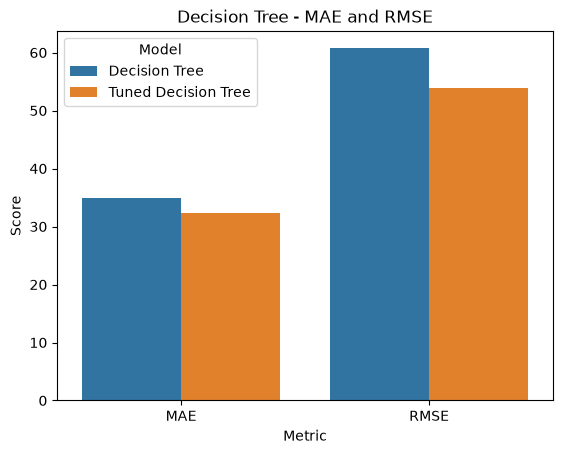

In [187]:
# MAE and RMSE Comparison for Decision Tree Models
models = ["Decision Tree", "Tuned Decision Tree"]
mae = [dt_mae, best_dt_mae]
rmse = [dt_rmse, best_dt_rmse]
dt_long = pd.DataFrame({
    "Model": models,
    "MAE": mae,
    "RMSE": rmse
}).melt(id_vars="Model", value_vars=["MAE", "RMSE"])
sns.barplot(data=dt_long, x="variable", y="value", hue="Model")
plt.title("Decision Tree - MAE and RMSE")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.show()

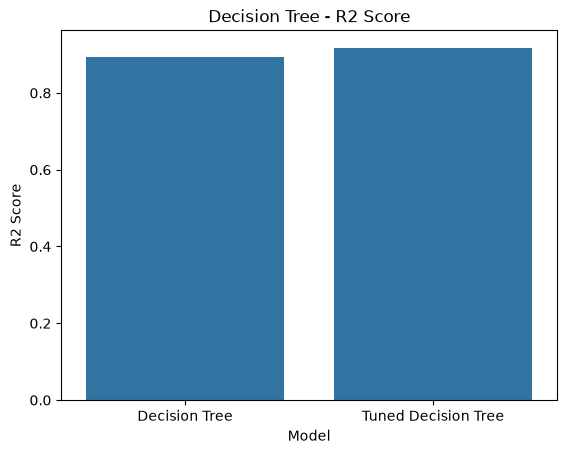

In [188]:
# R2 Score Comparison for Decision Tree Models
models = ["Decision Tree", "Tuned Decision Tree"]
r2 = [dt_r2, best_dt_r2]
sns.barplot(x=models, y=r2)
plt.title("Decision Tree - R2 Score")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.xticks(rotation=0)
plt.show()

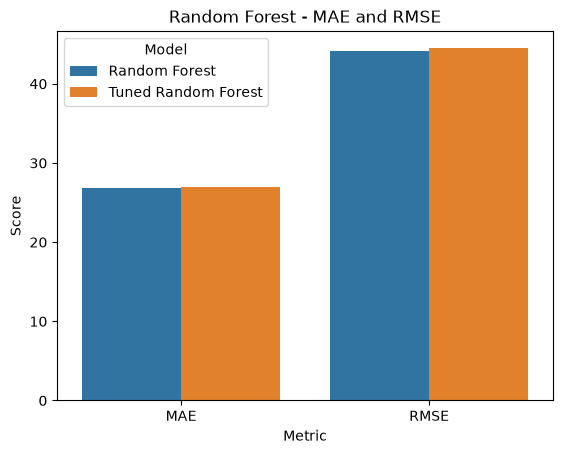

In [189]:
# MAE and RMSE Comparison for Random Forest Models
models = ["Random Forest", "Tuned Random Forest"]
mae = [rf_mae, best_rf_mae]
rmse = [rf_rmse, best_rf_rmse]
rf_long = pd.DataFrame({
    "Model": models,
    "MAE": mae,
    "RMSE": rmse
}).melt(id_vars="Model", value_vars=["MAE", "RMSE"])
sns.barplot(data=rf_long, x="variable", y="value", hue="Model")
plt.title("Random Forest - MAE and RMSE")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.show()

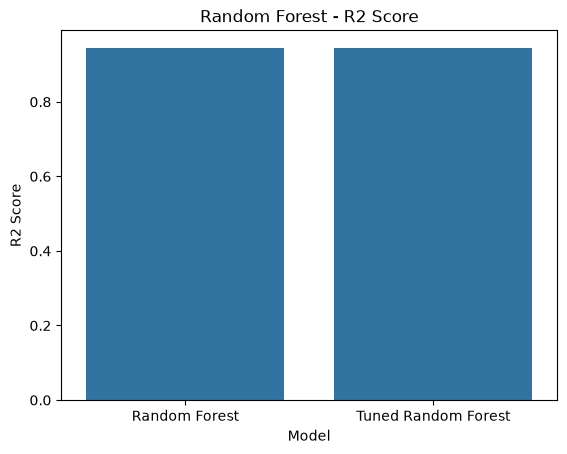

In [190]:
# R2 Score Comparison for Random Forest Models
models = ["Random Forest", "Tuned Random Forest"]
r2 = [rf_r2, best_rf_r2]
sns.barplot(x=models, y=r2)
plt.title("Random Forest - R2 Score")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.xticks(rotation=0)
plt.show()

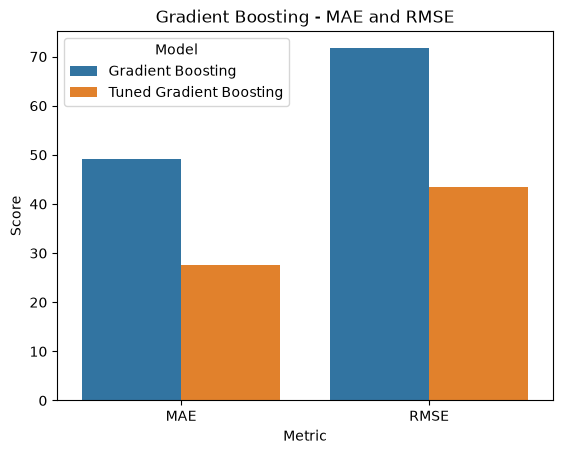

In [191]:
# MAE and RMSE Comparison for Gradient Boosting Models
models = ["Gradient Boosting", "Tuned Gradient Boosting"]
mae = [gb_mae, best_gb_mae]
rmse = [gb_rmse, best_gb_rmse]

gb_long = pd.DataFrame({
    "Model": models,
    "MAE": mae,
    "RMSE": rmse
}).melt(id_vars="Model", value_vars=["MAE", "RMSE"])

sns.barplot(data=gb_long, x="variable", y="value", hue="Model")

plt.title("Gradient Boosting - MAE and RMSE")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.show()

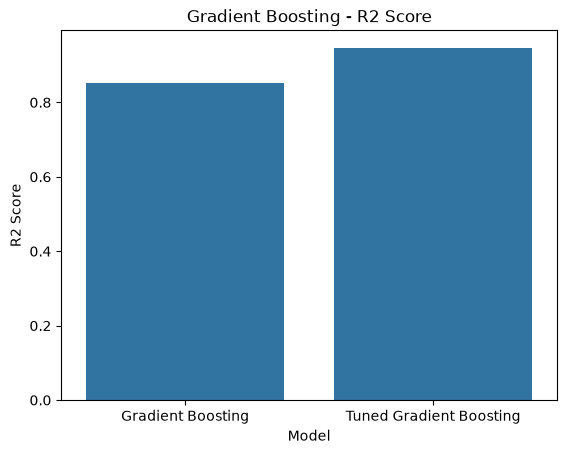

In [192]:
# R2 Score Comparison for Gradient Boosting Models
models = ["Gradient Boosting", "Tuned Gradient Boosting"]
r2 = [gb_r2, best_gb_r2]

sns.barplot(x=models, y=r2)

plt.title("Gradient Boosting - R2 Score")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.xticks(rotation=0)
plt.show()

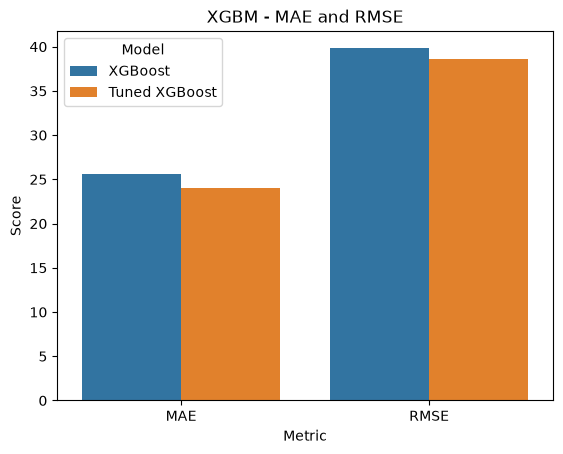

In [193]:
#MAE and RMSE Comparison for XGBM 
models = ["XGBoost", "Tuned XGBoost"]
mae = [xgb_mae, best_xgb_mae]
rmse = [xgb_rmse, best_xgb_rmse]

xgb_long = pd.DataFrame({
    "Model": models,
    "MAE": mae,
    "RMSE": rmse
}).melt(id_vars="Model", value_vars=["MAE", "RMSE"])

sns.barplot(data=xgb_long, x="variable", y="value", hue="Model")

plt.title("XGBM - MAE and RMSE")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.show()

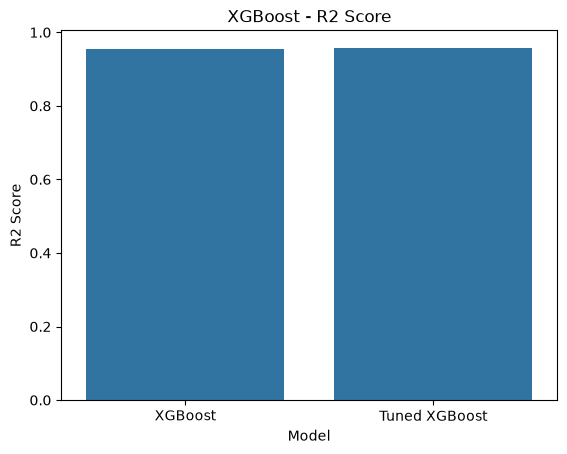

In [194]:
#R2 Score Comparison for XGBoost Models
models = ["XGBoost", "Tuned XGBoost"]
r2 = [xgb_r2, best_xgb_r2]

sns.barplot(x=models, y=r2)

plt.title("XGBoost - R2 Score")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.xticks(rotation=0)
plt.show()

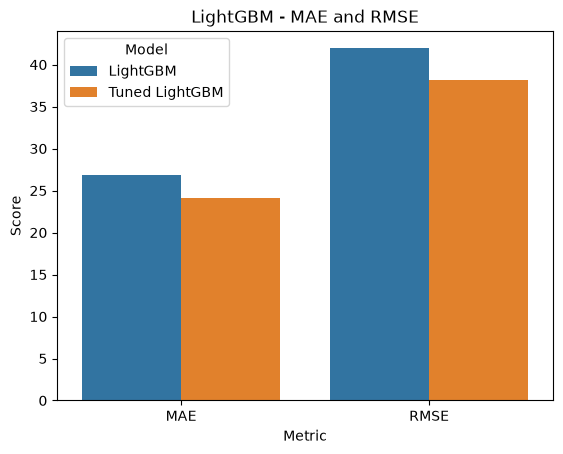

In [195]:
#MAE and RMSE Comparison for LightGBM Models
models = ["LightGBM", "Tuned LightGBM"]
mae = [lgb_mae, best_lgb_mae]
rmse = [lgb_rmse, best_lgb_rmse]

lgb_long = pd.DataFrame({
    "Model": models,
    "MAE": mae,
    "RMSE": rmse
}).melt(id_vars="Model", value_vars=["MAE", "RMSE"])

sns.barplot(data=lgb_long, x="variable", y="value", hue="Model")

plt.title("LightGBM - MAE and RMSE")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.show()

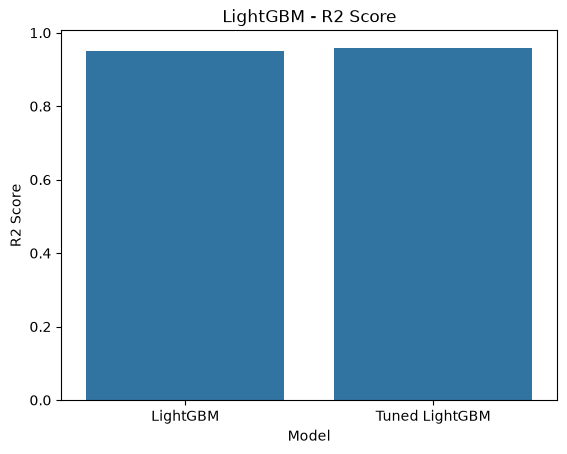

In [196]:
#R2 Score Comparison for LightGBM Models
models = ["LightGBM", "Tuned LightGBM"]
r2 = [lgb_r2, best_lgb_r2]

sns.barplot(x=models, y=r2)

plt.title("LightGBM - R2 Score")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.xticks(rotation=0)
plt.show()

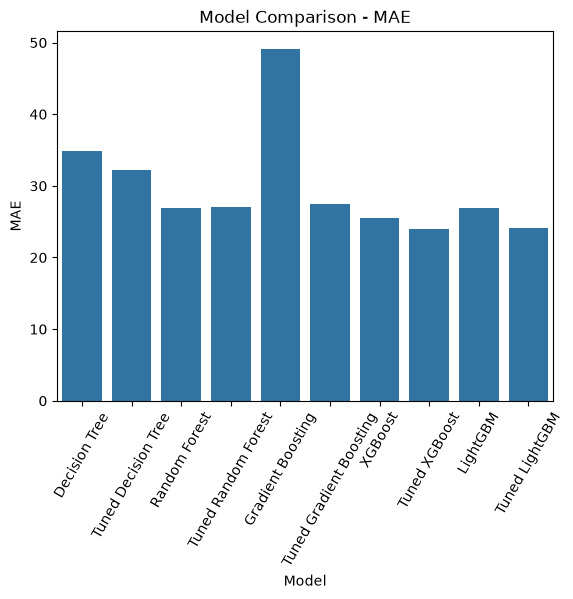

In [197]:
# MAE Comparison for All Models
models = [
    "Decision Tree",
    "Tuned Decision Tree",
    "Random Forest",
    "Tuned Random Forest",
    "Gradient Boosting",
    "Tuned Gradient Boosting",
    "XGBoost",
    "Tuned XGBoost",
    "LightGBM",
    "Tuned LightGBM"
]
mae = [
    dt_mae,
    best_dt_mae,
    rf_mae,
    best_rf_mae,
    gb_mae,
    best_gb_mae,
    xgb_mae,
    best_xgb_mae,
    lgb_mae,
    best_lgb_mae
]
sns.barplot(x=models, y=mae)
plt.title("Model Comparison - MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=60)
plt.show()

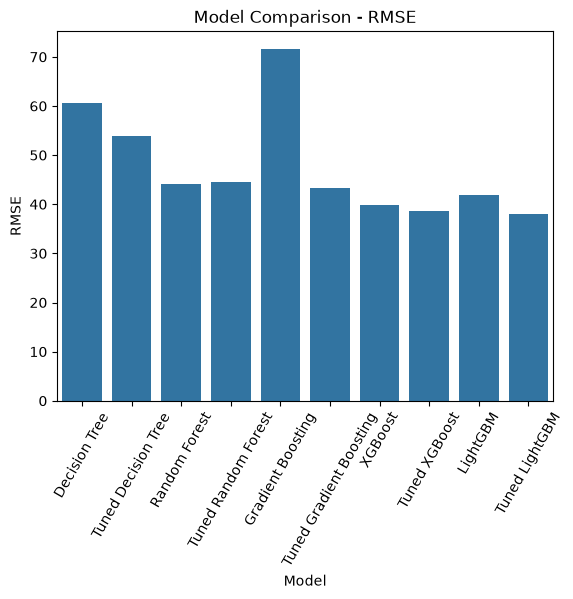

In [198]:
#RMSE Comparison for All Models
models = [
    "Decision Tree",
    "Tuned Decision Tree",
    "Random Forest",
    "Tuned Random Forest",
    "Gradient Boosting",
    "Tuned Gradient Boosting",
    "XGBoost",
    "Tuned XGBoost",
    "LightGBM",
    "Tuned LightGBM"
]
rmse = [
    dt_rmse,
    best_dt_rmse,
    rf_rmse,
    best_rf_rmse,
    gb_rmse,
    best_gb_rmse,
    xgb_rmse,
    best_xgb_rmse,
    lgb_rmse,
    best_lgb_rmse
]
sns.barplot(x=models, y=rmse)
plt.title("Model Comparison - RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=60)
plt.show()

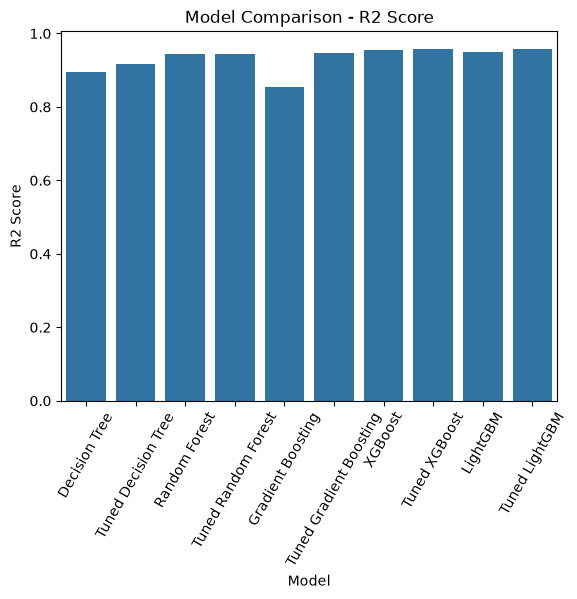

In [199]:
#R2 Score Comparison for All Models
models = [
    "Decision Tree",
    "Tuned Decision Tree",
    "Random Forest",
    "Tuned Random Forest",
    "Gradient Boosting",
    "Tuned Gradient Boosting",
    "XGBoost",
    "Tuned XGBoost",
    "LightGBM",
    "Tuned LightGBM"
]
r2 = [
    dt_r2,
    best_dt_r2,
    rf_r2,
    best_rf_r2,
    gb_r2,
    best_gb_r2,
    xgb_r2,
    best_xgb_r2,
    lgb_r2,
    best_lgb_r2
]
sns.barplot(x=models, y=r2)
plt.title("Model Comparison - R2 Score")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.xticks(rotation=60)
plt.show()

In [201]:
#Final comparison of all 10 models
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "LightGBM",
        "Tuned Decision Tree",
        "Tuned Random Forest",
        "Tuned Gradient Boosting",
        "Tuned XGBoost",
        "Tuned LightGBM"
    ],
    "MAE": [
        dt_mae,
        rf_mae,
        gb_mae,
        xgb_mae,
        lgb_mae,
        best_dt_mae,
        best_rf_mae,
        best_gb_mae,
        best_xgb_mae,
        best_lgb_mae
    ],
    "RMSE": [
        dt_rmse,
        rf_rmse,
        gb_rmse,
        xgb_rmse,
        lgb_rmse,
        best_dt_rmse,
        best_rf_rmse,
        best_gb_rmse,
        best_xgb_rmse,
        best_lgb_rmse
    ],
    "R2": [
        dt_r2,
        rf_r2,
        gb_r2,
        xgb_r2,
        lgb_r2,
        best_dt_r2,
        best_rf_r2,
        best_gb_r2,
        best_xgb_r2,
        best_lgb_r2
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Decision Tree,34.847239,60.703377,0.894457
1,Random Forest,26.879781,44.149905,0.944171
2,Gradient Boosting,49.141650,71.651534,0.852954
3,XGBoost,25.571024,39.795214,0.954641
4,LightGBM,26.873962,41.921954,0.949663
5,Tuned Decision Tree,32.261608,53.868476,0.916886
6,Tuned Random Forest,27.001926,44.459125,0.943386
7,Tuned Gradient Boosting,27.538111,43.397171,0.946058
8,Tuned XGBoost,24.033678,38.657096,0.957198
9,Tuned LightGBM,24.087468,38.114806,0.958391


In [202]:
comparison.round(3)

,Model,MAE,RMSE,R2
0,Decision Tree,34.847,60.703,0.894
1,Random Forest,26.880,44.150,0.944
2,Gradient Boosting,49.142,71.652,0.853
3,XGBoost,25.571,39.795,0.955
4,LightGBM,26.874,41.922,0.950
5,Tuned Decision Tree,32.262,53.868,0.917
6,Tuned Random Forest,27.002,44.459,0.943
7,Tuned Gradient Boosting,27.538,43.397,0.946
8,Tuned XGBoost,24.034,38.657,0.957
9,Tuned LightGBM,24.087,38.115,0.958


### Best Model

In [203]:
#Finding the best model based on R2 Score
models = [
    "Decision Tree",
    "Tuned Decision Tree",
    "Random Forest",
    "Tuned Random Forest",
    "Gradient Boosting",
    "Tuned Gradient Boosting",
    "XGBoost",
    "Tuned XGBoost",
    "LightGBM",
    "Tuned LightGBM"
]

In [204]:
r2 = [
    dt_r2,
    best_dt_r2,
    rf_r2,
    best_rf_r2,
    gb_r2,
    best_gb_r2,
    xgb_r2,
    best_xgb_r2,
    lgb_r2,
    best_lgb_r2
]

In [205]:
mae = [
    dt_mae,
    best_dt_mae,
    rf_mae,
    best_rf_mae,
    gb_mae,
    best_gb_mae,
    xgb_mae,
    best_xgb_mae,
    lgb_mae,
    best_lgb_mae
]

In [206]:
rmse = [
    dt_rmse,
    best_dt_rmse,
    rf_rmse,
    best_rf_rmse,
    gb_rmse,
    best_gb_rmse,
    xgb_rmse,
    best_xgb_rmse,
    lgb_rmse,
    best_lgb_rmse
]

In [207]:
best_index = r2.index(max(r2))

In [208]:
print("Best Model:", models[best_index])
print("MAE:", mae[best_index])
print("RMSE:", rmse[best_index])
print("R2 Score:", r2[best_index])

Best Model: Tuned LightGBM
MAE: 24.087468366599552
RMSE: 38.114806099927414
R2 Score: 0.9583906488686625


### Conclusion

The bike-sharing dataset was analyzed through data cleaning, exploratory data analysis, feature engineering, and machine learning. Several useful features were created to improve the models, and categorical variables were converted into numerical form.

Five regression models were built and compared: Decision Tree, Random Forest, Gradient Boosting, XGBoost, and LightGBM. Hyperparameter tuning was then performed using GridSearchCV to improve the performance of each model.

Among the tuned models, the Tuned LightGBM Regressor achieved the highest R2 score and the lowest RMSE, while the Tuned XGBoost Regressor achieved a slightly lower MAE. Overall, Tuned LightGBM provided the best performance based on R² and RMSE.

Therefore, the Tuned LightGBM Regressor was selected as the final model for predicting bike rental demand.